In [21]:
import os
from pathlib import Path
from glob import glob

import torch
import numpy as np
import albumentations as A
from torch.utils.data import Dataset

from PIL import Image, ImageFilter
import random

import torchvision.transforms as T

class TwoCropsTransform:
    """Take two random crops of one image as the query and key."""

    def __init__(self, base_transform) -> None:
        self.base_transform = base_transform

    def __call__(self, x):
        q = self.base_transform(x)
        k = self.base_transform(x)
        return [q, k]


class GaussianBlur:
    """Gaussian blur augmentation in SimCLR https://arxiv.org/abs/2002.05709"""

    def __init__(self, sigma=[0.1, 2.0]) -> None:
        self.sigma = sigma

    def __call__(self, x):
        sigma = random.uniform(self.sigma[0], self.sigma[1])
        x = x.filter(ImageFilter.GaussianBlur(radius=sigma))
        return x

def get_uav_img_paths(data_root='../../data/'):
    data_root = Path(data_root)

    uav_root = data_root / 'UAVid'
    if not uav_root.exists():
        raise FileNotFoundError(f'UAVid dataset not found in {uav_root}')
    uav_folders = ['uavid_train']
    img_paths = []
    for folder in uav_folders:
        paths = sorted(glob(str(uav_root / folder / 'seq*' / 'Images' / '*.png')))
        img_paths.extend(paths)

    udd_root = data_root / 'UDD'
    if not udd_root.exists():
        raise FileNotFoundError(f'UDD dataset not found in {udd_root}')
    paths = sorted(glob(str(udd_root / '*.JPG')))
    img_paths.extend(paths)

    semantic_drone = data_root / 'semantic_drone' / 'images'
    if not semantic_drone.exists():
        raise FileNotFoundError(f'Semantic Drone dataset not found in {semantic_drone}')
    paths = sorted(glob(str(semantic_drone / '*.jpg')))
    img_paths.extend(paths)

    
    print(f'Total {len(img_paths)} images found for MoCo training')
    return img_paths

def get_moco_transform(patch_size=224, version=2):
    if version == 2:
        return T.Compose([
            T.RandomResizedCrop(patch_size, scale=(0.5, 1.0)),
            T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
            T.RandomGrayscale(p=0.2),
            T.RandomApply([GaussianBlur([0.1, 2.0])], p=0.5),
            T.RandomHorizontalFlip(p=0.5),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
    elif version == 1:
        return T.Compose([
            T.RandomResizedCrop(patch_size, scale=(0.2, 1.0)),
            T.RandomGrayscale(p=0.2),
            T.ColorJitter(0.4, 0.4, 0.4, 0.4),
            T.RandomHorizontalFlip(p=0.5),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])


class UAVMocoDataset(Dataset):
    def __init__(self, img_paths, patch_size=224, moco_version=2):
        self.img_paths = img_paths
        self.patch_size = patch_size
        self.transform = get_moco_transform(patch_size, version=moco_version)
        self.basic_transform = T.Compose([
            T.Resize((patch_size, patch_size)),
            T.ToTensor(),
            T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])
        self.two_crops_transform = TwoCropsTransform(self.transform)

    def __len__(self):
        return len(self.img_paths)

    def _load_image(self, path):
        return Image.open(path).convert('RGB')

    def __getitem__(self, idx):
        img_path = self.img_paths[idx]
        img = self._load_image(img_path)

        im_q, im_k = self.two_crops_transform(img)
        img = self.basic_transform(img)
        return img, im_q, im_k


In [22]:
from torch.utils.data import DataLoader

DATA_DIR = '../data/'
img_paths = get_uav_img_paths(data_root=DATA_DIR)

dataset = UAVMocoDataset(img_paths, patch_size=224, moco_version=2)
loader = DataLoader(
    dataset,
    batch_size=2,
    shuffle=True,
    num_workers=1,
    pin_memory=True,
    drop_last=True,
)


Total 888 images found for MoCo training


In [23]:
import matplotlib.pyplot as plt
import torchvision

def imshow(img, title=None):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    if title is not None:
        plt.title(title)
    plt.axis('off')


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3791421..1.82].


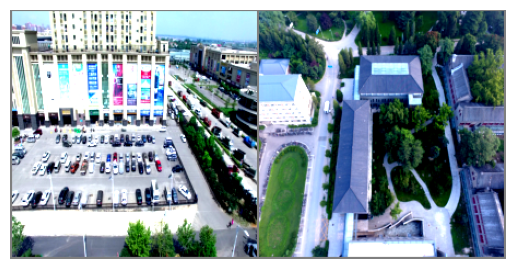

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.5332649..1.584706].


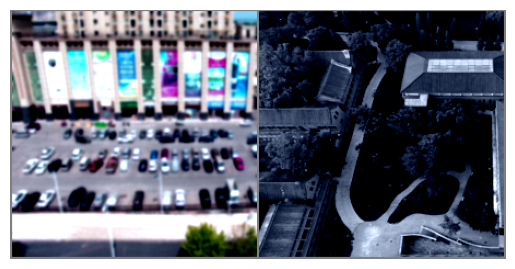

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.48189062..1.732854].


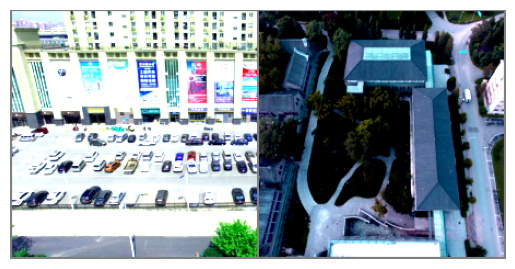

In [24]:

dataiter = iter(loader)
img, images_q, images_k = next(dataiter)

imshow(torchvision.utils.make_grid(img[:8]))
plt.show()
# Show query images
imshow(torchvision.utils.make_grid(images_q[:8]))
plt.show()
# Show key images
imshow(torchvision.utils.make_grid(images_k[:8]))
plt.show()
